Urban Traffic Flow & Congestion Analytics Project-solutions

SECTION 0: PROJECT SETUP

Notebook Structure
Organize your Jupyter Notebook like this:
1. Introduction
2. Data Loading
3. Data Understanding
4. Data Cleaning
5. Data Validation
6. Feature Engineering
7. KPI Framework
8. Traffic Analysis
9. Advanced Analytics
10. Visualization
11. Dashboard
12. Strategy


Import Libraries

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.7 MB 4.4 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.7 MB 3.7 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.7 MB 3.6 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.7 MB 3.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.7 MB 3.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.7 MB 3.2 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.7 MB 2.6 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.7 MB 2.6 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.7 MB 2.1 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.7 MB 2.1 MB/s eta 0:00:03
   ------------------ --

In [4]:
pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 4.0 MB/s eta 0:00:01
   --------- ------------------------------ 0.5/2.2 MB 4.0 MB/s eta 0:00:01
   -------------- ------------------------- 0.8/2.2 MB 975.5 kB/s eta 0:00:02
   -------------- ------------------------- 0.8/2.2 MB 975.5 kB/s eta 0:00:02
   -------------- ------------------------- 0.8/2.2 MB 975.5 kB/s eta 0:00:02
   ------------------ --------------------- 1.0/2.2 MB 778.2 kB/s eta 0:00:02
   ------------------ --------------------- 1.0/2.2 MB 778.2 kB/s eta 0:00:02
   ----------------------- ---------------- 1.3/2.2 MB 690.9 kB/s eta 0:00:02
   ----------------------- ---------------- 1.3/2.2 MB 690.9 kB/s eta 0:00:02
   ----------------------- ---------------- 1.3/2.2 MB 690.9 kB/s eta 0:00:02
   -----

In [5]:
import plotly.express as px
import ipywidgets as widgets

PART A: DATA UNDERSTANDING & TRAFFIC CONTEXT

TASK 1: Load & Inspect Dataset

Step 1: Load Data

In [6]:
import os

In [7]:
import os
os.chdir(r"C:\Users\Athmi shetty\OneDrive\Documents\GitHub\assignmentfile")
print(os.getcwd())  # confirm it changed

C:\Users\Athmi shetty\OneDrive\Documents\GitHub\assignmentfile


In [9]:
df = pd.read_csv(r"C:\Users\Athmi shetty\OneDrive\Documents\GitHub\assignmentfile\bangloe traffic analysis\bangloe traffic analysis\Banglore_traffic_Dataset.csv")

Step 2: Initial Inspection

In [10]:
df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   str    
 1   Area Name                           8936 non-null   str    
 2   Road/Intersection Name              8936 non-null   str    
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compliance           8936 non-null   fl

In [12]:
df.shape

(8936, 16)

In [13]:
df.describe()

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
count,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000
mean,29236.048120,39.447427,1.375554,80.818041,92.029215,1.570389,108.472096,45.086651,79.950243,75.155597,114.533348
std,13001.808801,10.707244,0.165319,23.533182,16.583341,1.420047,26.003618,20.208460,11.585006,14.409394,36.812573
min,4233.000000,20.000000,1.000039,5.160279,18.739771,0.000000,58.466000,10.006853,60.003933,50.020411,66.000000
25%,19413.000000,31.775825,1.242459,64.292905,97.354990,0.000000,88.826000,27.341191,69.828270,62.545895,94.000000
50%,27600.000000,39.199368,1.500000,92.389018,100.000000,1.000000,105.200000,45.170684,79.992773,75.317610,102.000000
75%,38058.500000,46.644517,1.500000,100.000000,100.000000,2.000000,126.117000,62.426485,89.957358,87.518589,111.000000
max,72039.000000,89.790843,1.500000,100.000000,100.000000,10.000000,194.078000,79.979744,99.993652,99.995049,243.000000


By reading the dataset you can understand the how the traffic is being mesured and recorded

TASK 2: Identify Reference Fields


In [14]:
df.columns

Index(['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume',
       'Average Speed', 'Travel Time Index', 'Congestion Level',
       'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact',
       'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage',
       'Pedestrian and Cyclist Count', 'Weather Conditions',
       'Roadwork and Construction Activity'],
      dtype='str')

TASK 3: Prepare Analytical View

Step 1: Standardize Columns

In [22]:
df.columns = df.columns.str.lower().str.replace(" ","_")

Step 2: Convert Date-Time

In [34]:
df['date'] = pd.to_datetime(df['date'])



datetime64[us]


In [33]:
df['hour'] = pd.to_datetime(df['travel_time_index']).dt.hour

Step 3: Handle Missing Values

In [27]:
df.isnull().sum()
df.fillna(df.median(numeric_only=True), inplace=True)


,date,area_name,road/intersection_name,traffic_volume,average_speed,travel_time_index,congestion_level,road_capacity_utilization,incident_reports,environmental_impact,public_transport_usage,traffic_signal_compliance,parking_usage,pedestrian_and_cyclist_count,weather_conditions,roadwork_and_construction_activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8931,2024-08-09,Electronic City,Hosur Road,11387,23.440276,1.262384,35.871483,57.354487,1,72.774,21.523289,83.530352,97.898279,211,Fog,No
8932,2024-08-09,M.G. Road,Trinity Circle,36477,45.168429,1.500000,100.000000,100.000000,3,122.954,29.822312,60.738488,60.355967,95,Clear,No
8933,2024-08-09,M.G. Road,Anil Kumble Circle,42822,22.028609,1.500000,100.000000,100.000000,1,135.644,43.185905,85.321627,61.333731,110,Clear,No
8934,2024-08-09,Jayanagar,South End Circle,20540,52.254798,1.020520,72.639152,97.845527,2,91.080,44.416043,89.586947,79.197198,94,Clear,No


Time based analysis needs proper date/hour format and missing values distort congestion estimtes

TASK 4: Validation

Step 1: Record Count

In [28]:
len(df)

8936

Step 2: Time Coverage

In [36]:
df['date'].min()

Timestamp('2022-01-01 00:00:00')

In [37]:
df['date'].max()

Timestamp('2024-08-09 00:00:00')

Step 3: Location Coverage

In [31]:
df['area_name'].nunique()

8

TASK 5: Preparation Impact

In [32]:
(df.isnull().mean()*100).sort_values(ascending=False)

date                                  0.0
area_name                             0.0
road/intersection_name                0.0
traffic_volume                        0.0
average_speed                         0.0
travel_time_index                     0.0
congestion_level                      0.0
road_capacity_utilization             0.0
incident_reports                      0.0
environmental_impact                  0.0
public_transport_usage                0.0
traffic_signal_compliance             0.0
parking_usage                         0.0
pedestrian_and_cyclist_count          0.0
weather_conditions                    0.0
roadwork_and_construction_activity    0.0
dtype: float64

•	Dropped rows → missing periods
•	Filled values → smoothing effect


PART B: DATA RELIABILITY & PATTERN REVIEW

TASK 6: Quality Audit

In [39]:
df.duplicated().sum()
df[df['traffic_volume'] < 0]
df[df['average_speed'] < 0]


,date,area_name,road/intersection_name,traffic_volume,average_speed,travel_time_index,congestion_level,road_capacity_utilization,incident_reports,environmental_impact,public_transport_usage,traffic_signal_compliance,parking_usage,pedestrian_and_cyclist_count,weather_conditions,roadwork_and_construction_activity,hour


TASK 7: Chronological Review

In [40]:
df['day_name'] = df['date'].dt.day_name()

In [41]:
df.groupby('hour')['traffic_volume'].mean()

hour
0    29236.04812
Name: traffic_volume, dtype: float64

Check:
•	Morning peak
•	Evening peak
Traffic must follow daily cycles.

TASK 8: Volume vs Congestion Consistency

<Axes: xlabel='traffic_volume', ylabel='congestion_level'>

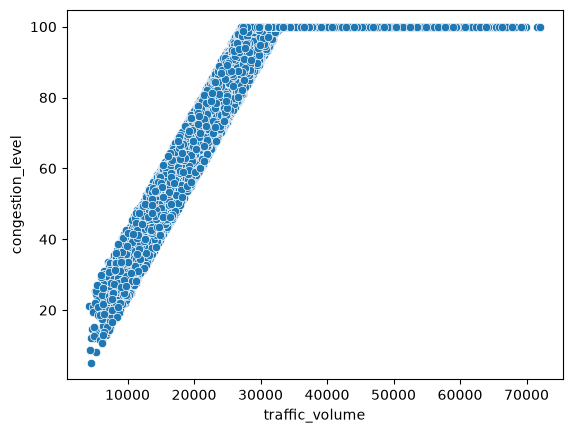

In [42]:
sns.scatterplot(
    x='traffic_volume',
    y='congestion_level',
    data=df
)


In [44]:
df[['traffic_volume','average_speed','congestion_level']].corr()

,traffic_volume,average_speed,congestion_level
traffic_volume,1.000000,-0.341138,0.837218
average_speed,-0.341138,1.000000,-0.360250
congestion_level,0.837218,-0.360250,1.000000


High volume → low speed → high congestion
If not → data issue


TASK 9: Abnormal Patterns

In [45]:
df['z_score'] = (
    df['traffic_volume'] - df['traffic_volume'].mean()
) / df['traffic_volume'].std()


In [46]:
df[df['z_score'] > 3]

,date,area_name,road/intersection_name,traffic_volume,average_speed,travel_time_index,congestion_level,road_capacity_utilization,incident_reports,environmental_impact,public_transport_usage,traffic_signal_compliance,parking_usage,pedestrian_and_cyclist_count,weather_conditions,roadwork_and_construction_activity,hour,day_name,z_score
587,2022-03-04,Koramangala,Sarjapur Road,69293,31.289433,1.5,100.0,100.0,2,188.586,74.787053,93.157196,55.449999,85,Clear,No,0,Friday,3.080875
1653,2022-06-26,Koramangala,Sony World Junction,69874,37.312763,1.5,100.0,100.0,0,189.748,34.511645,84.957769,59.616618,88,Clear,No,0,Sunday,3.125561
2002,2022-08-01,Koramangala,Sarjapur Road,71610,39.584985,1.5,100.0,100.0,0,193.220,21.310529,61.201513,82.907808,104,Clear,No,0,Monday,3.259081
2314,2022-09-03,Koramangala,Sony World Junction,69407,44.732284,1.5,100.0,100.0,2,188.814,53.053770,93.145602,82.897385,96,Clear,No,0,Saturday,3.089643
2814,2022-10-26,Koramangala,Sony World Junction,69272,37.308145,1.5,100.0,100.0,2,188.544,59.627333,79.075286,84.937678,101,Clear,No,0,Wednesday,3.079260
4010,2023-03-05,Koramangala,Sarjapur Road,69494,54.624294,1.5,100.0,100.0,1,188.988,39.062034,75.435380,56.377915,96,Rain,No,0,Sunday,3.096335
5392,2023-08-02,Koramangala,Sony World Junction,68275,38.300460,1.5,100.0,100.0,1,186.550,74.318818,62.732900,55.235440,88,Clear,No,0,Wednesday,3.002579
6072,2023-10-11,Koramangala,Sony World Junction,72039,29.983761,1.5,100.0,100.0,2,194.078,61.858975,79.324487,77.714041,95,Clear,No,0,Wednesday,3.292077
8898,2024-08-06,Koramangala,Sony World Junction,69158,21.640951,1.5,100.0,100.0,3,188.316,38.522493,99.539971,55.337992,92,Clear,No,0,Tuesday,3.070492


Finds extreme jams or accidents.

PART C: TRAFFIC METRICS & FLOW INDICATORS
________________________________________


TASK 10: New Variables

Peak Indicator

In [47]:
df['is_peak'] = df['hour'].between(8,10) | df['hour'].between(17,19)

Congestion Persistence

In [50]:
df['high_congestion'] = (df['congestion_level'] > 7).astype(int)

Delay Severity


In [49]:
df['delay_index'] = df['traffic_volume'] / df['average_speed']

TASK 11: KPIs

KPI	Formula
Avg Speed-Mean(speed)
Peak Load-Avg volume (peak)
Delay Index-Volume/Speed
Reliability-% low congestion


In [53]:
kpi = df.groupby('area_name').agg({
    'average_speed':'mean',
    'delay_index':'mean',
    'high_congestion':'mean'
})


TASK 12: Location Profiles

In [54]:
location_profile = df.groupby('area_name').agg({
    'traffic_volume':'mean',
    'average_speed':'mean',
    'congestion_level':'mean'
})

TASK 13: Area Influence

In [56]:
df.groupby('z_score')['congestion_level'].mean()

z_score
-1.923044     21.163532
-1.913661      8.744589
-1.904739      5.160279
-1.899662     12.115199
-1.884511     14.688471
                ...    
 3.089643    100.000000
 3.096335    100.000000
 3.125561    100.000000
 3.259081    100.000000
 3.292077    100.000000
Name: congestion_level, Length: 8100, dtype: float64

PART D: PERFORMANCE ANALYSIS

TASK 14: Trend Analysis

<Axes: xlabel='date'>

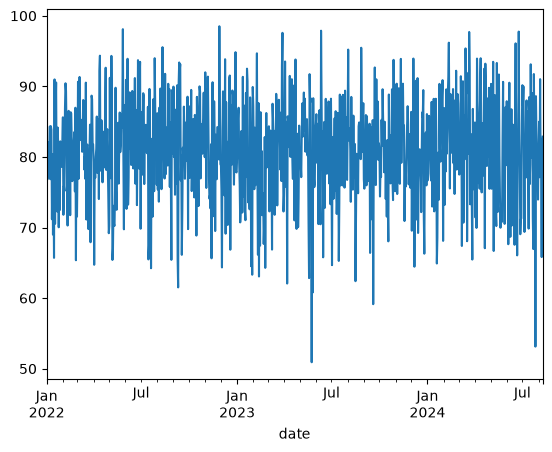

In [57]:
daily = df.groupby('date')['congestion_level'].mean()
daily.plot()


In [58]:
df.groupby('day_name')['traffic_volume'].mean()

day_name
Friday       28842.780527
Monday       29510.237654
Saturday     29062.983721
Sunday       29105.277516
Thursday     29530.357600
Tuesday      28911.255157
Wednesday    29697.560821
Name: traffic_volume, dtype: float64

TASK 15: Group Analysis

In [60]:
df.groupby('hour')['congestion_level'].mean()
df.groupby('road/intersection_name')['traffic_volume'].mean()


road/intersection_name
100 Feet Road          31956.852326
Anil Kumble Circle     35251.828722
Ballari Road           26272.640756
CMH Road               32611.924419
Hebbal Flyover         26794.924051
Hosur Road             16557.223827
ITPL Main Road         21866.037778
Jayanagar 4th Block    24496.236207
Marathahalli Bridge    20772.953252
Sarjapur Road          40189.950000
Silk Board Junction    16134.534545
Sony World Junction    41470.801170
South End Circle       24704.119730
Trinity Circle         35350.137466
Tumkur Road            18574.490305
Yeshwanthpur Circle    19277.115282
Name: traffic_volume, dtype: float64

TASK 16: Bottleneck Identification

In [62]:
bottlenecks = df.groupby('area_name')['delay_index'].mean()
bottlenecks.sort_values(ascending=False).head(10)


area_name
Koramangala        1242.904404
M.G. Road          1033.271428
Indiranagar         937.532591
Hebbal              745.202168
Jayanagar           690.219063
Whitefield          562.624437
Yeshwanthpur        482.265800
Electronic City     409.139721
Name: delay_index, dtype: float64

These are priority intervention zones.

TASK 17: Network Efficiency

In [64]:
df['efficiency'] = df['average_speed'] / df['traffic_volume']

In [65]:
df.groupby('area_name')['efficiency'].mean()

area_name
Electronic City    0.003297
Hebbal             0.001898
Indiranagar        0.001482
Jayanagar          0.001981
Koramangala        0.001081
M.G. Road          0.001295
Whitefield         0.002441
Yeshwanthpur       0.002810
Name: efficiency, dtype: float64

TASK 18: Equity Analysis

In [67]:
df.groupby('z_score')['congestion_level'].mean()

z_score
-1.923044     21.163532
-1.913661      8.744589
-1.904739      5.160279
-1.899662     12.115199
-1.884511     14.688471
                ...    
 3.089643    100.000000
 3.096335    100.000000
 3.125561    100.000000
 3.259081    100.000000
 3.292077    100.000000
Name: congestion_level, Length: 8100, dtype: float64

PART E: ADVANCED ANALYTICS

TASK 19: Expected Traffic Model

In [68]:
df['expected_volume'] = df.groupby(
    ['hour','day_name']
)['traffic_volume'].transform('mean')


In [69]:
df['volume_gap'] = df['traffic_volume'] - df['expected_volume']

TASK 20: High-Risk Zone Detection

In [70]:
df['risk_flag'] = (
    (df['congestion_level'] > 7) &
    (df['delay_index'] > df['delay_index'].quantile(0.75))
).astype(int)


Identifies critical congestion zones.

TASK 21: Breakdown Analysis

In [71]:
df[df['volume_gap'] > df['volume_gap'].quantile(0.95)]

,date,area_name,road/intersection_name,traffic_volume,average_speed,travel_time_index,congestion_level,road_capacity_utilization,incident_reports,environmental_impact,...,hour,day_name,z_score,is_peak,delay_index,high_congestion,efficiency,expected_volume,volume_gap,risk_flag
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.5,100.0,100.0,1,171.748,...,0,Saturday,2.433350,False,1389.258781,1,0.000720,29062.983721,31811.016279,1
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.5,100.0,100.0,3,164.584,...,0,Saturday,2.157850,False,1393.397631,1,0.000718,29062.983721,28229.016279,1
15,2022-01-02,M.G. Road,Trinity Circle,53217,37.572075,1.5,100.0,100.0,5,156.434,...,0,Sunday,1.844432,False,1416.397687,1,0.000706,29105.277516,24111.722484,1
31,2022-01-04,Indiranagar,CMH Road,56242,52.553408,1.5,100.0,100.0,0,162.484,...,0,Tuesday,2.077092,False,1070.187485,1,0.000934,28911.255157,27330.744843,0
44,2022-01-05,Koramangala,Sony World Junction,58920,25.212363,1.5,100.0,100.0,2,167.840,...,0,Wednesday,2.283063,False,2336.948757,1,0.000428,29697.560821,29222.439179,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8862,2024-08-02,M.G. Road,Anil Kumble Circle,56673,27.398552,1.5,100.0,100.0,2,163.346,...,0,Friday,2.110241,False,2068.466947,1,0.000483,28842.780527,27830.219473,1
8873,2024-08-03,M.G. Road,Trinity Circle,53539,29.029549,1.5,100.0,100.0,2,157.078,...,0,Saturday,1.869198,False,1844.293195,1,0.000542,29062.983721,24476.016279,1
8881,2024-08-04,Koramangala,Sony World Junction,57795,27.829490,1.5,100.0,100.0,1,165.590,...,0,Sunday,2.196537,False,2076.753805,1,0.000482,29105.277516,28689.722484,1
8898,2024-08-06,Koramangala,Sony World Junction,69158,21.640951,1.5,100.0,100.0,3,188.316,...,0,Tuesday,3.070492,False,3195.700598,1,0.000313,28911.255157,40246.744843,1


TASK 22: Demand vs Capacity

<Axes: xlabel='traffic_volume', ylabel='average_speed'>

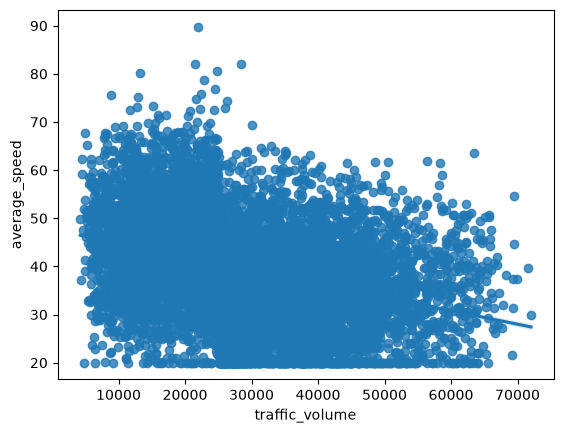

In [73]:
sns.regplot(
    x='traffic_volume',
    y='average_speed',
    data=df
)


PART F: MOBILITY DASHBOARD

TASK 23: Interactive Interface

In [ ]:
loc_dd = widgets.Dropdown(
    options=df['area_name'].unique()
)

def update(l):
    d = df[df['area_name']==l]
    fig = px.line(d, x='hour', y='congestion_level')
    fig.show()

widgets.interact(update, l=loc_dd)


TASK 24: Scenario Simulation

Reduce peak volume by 15%

In [ ]:
df_sim = df.copy()

df_sim.loc[df_sim['is_peak'], 'traffic_volume'] *= 0.85

df_sim['delay_index'].mean()
